# 06 — Functional Interpretability



This notebook visualises and interprets the final functional classification results

without retraining the heavy models from the final modelling notebooks.
It combines:

- class-level spectral structure

- FPCA / FPLS score-space separation

- distance-based interpretability

- linear-model weight functions




Main goals:

1. load saved interpretability payload from the final functional

2. visualise global class differences

3. visualise FPCA and FPLS class separation

4. visualise a nearest-neighbour example

5. visualise local and global distance contribution curves

6. visualise functional logistic regression and linear SVM weight curves



Main exported outputs:

- coefficient_curves_raw.csv

- top_logreg_regions_raw.csv

- top_svm_regions_raw.csv

- fig_class_mean_spectra_raw.svg

- fig_mean_difference_raw.svg

- fig_fpca_scatter.svg

- fig_fpls_scatter.svg

- fig_nearest_neighbour_example.svg

- fig_local_distance_contribution.svg

- fig_global_distance_contribution.svg

- fig_beta_logreg_raw.svg

- fig_beta_svm_raw.svg

- fig_beta_compare_raw.svg

 

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import pairwise_distances

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Configuration

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "og_data"

FINAL_RESULTS_DIR = BASE_DIR / "results" / "04_final_functional_models"
OUT_DIR = BASE_DIR / "results" / "06_interpretability"
OUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = DATA_DIR / "xp_sampled_spectra.csv"
FINAL_PAYLOAD_FILE = FINAL_RESULTS_DIR / "interpretability_payload.npz"

TARGET_COL = "y"
SOURCE_ID_COL = "source_id"

CLASS_NAME_MAP = {
    0: "Nedvinarė",
    1: "Dvinarė",
}

MODEL_NAME_MAP = {
    "logreg": "Funkcinė logistinė regresija",
    "svm": "Funkcinis tiesinis SVM",
}

RAW_LABEL = "Neapdoroti duomenys"

## 2. Plot style

In [3]:
COLOR_PRIMARY = "#104A7E"     
COLOR_SECONDARY = "#78003F"  
COLOR_DARK = "#0D1530"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

SMOOTH_COLORS = {
    0.0: "#4A4A4A",
    2.0: "#6193CD",
    4.0: "#8DB3E2",
    6.0: "#B7D0EE",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def apply_clean_axes(ax, add_grid: bool = False, grid_axis: str = "y") -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if add_grid:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.6, alpha=0.5, color=COLOR_LIGHT)
    else:
        ax.grid(False)


def save_fig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close()


## 3. Helper functions

In [4]:
def l2_normalise_rows(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return X / norms

def normalise_curve_for_plot(beta):
    max_abs = np.max(np.abs(beta))
    if max_abs == 0:
        return beta
    return beta / max_abs


def infer_wavelength_columns(df: pd.DataFrame) -> list[str]:
    wl_cols = [c for c in df.columns if c.startswith("wl_")]
    if wl_cols:
        return sorted(wl_cols, key=lambda x: float(x.split("_")[1]))

    flux_cols = [c for c in df.columns if c.startswith("flux_")]
    if flux_cols:
        return sorted(flux_cols, key=lambda x: int(x.split("_")[1]))

    raise ValueError("Could not find spectral columns. Expected columns like wl_336 or flux_0.")


def build_global_knn_contribution(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    nn = pairwise_distances(X, X, metric="euclidean")
    np.fill_diagonal(nn, np.inf)
    nearest_idx = np.argmin(nn, axis=1)
    all_abs_diffs = np.abs(X - X[nearest_idx])
    return all_abs_diffs.mean(axis=0), nearest_idx


def top_weight_regions(
    wavelengths: np.ndarray,
    weights: np.ndarray,
    top_n: int = 15,
    weight_name: str = "weight",
) -> pd.DataFrame:
    df = pd.DataFrame({
        "wavelength": wavelengths,
        weight_name: weights,
        f"abs_{weight_name}": np.abs(weights),
    })
    return df.nlargest(top_n, f"abs_{weight_name}").reset_index(drop=True)


def safe_model_key(model_name: str) -> str:
    return (
        model_name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("=", "_")
        .replace(".", "_")
        .replace("-", "_")
    )


def extract_weight_curve_from_payload(payload, model_name: str) -> np.ndarray:
    key = f"weights_{safe_model_key(model_name)}"
    if key not in payload.files:
        raise KeyError(f"Missing weight curve in payload: {key}")
    return payload[key]


def sigma_label(sigma: float) -> str:
    return "Raw" if float(sigma) == 0.0 else f"σ={sigma:.1f}"


## 4. Load dataset and payloads

In [5]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

if not FINAL_PAYLOAD_FILE.exists():
    raise FileNotFoundError(f"Final interpretability payload not found: {FINAL_PAYLOAD_FILE}")


df = pd.read_csv(INPUT_FILE)
final_payload = np.load(FINAL_PAYLOAD_FILE)

wl_cols = infer_wavelength_columns(df)
wavelengths_from_df = np.array([float(col.split("_")[1]) for col in wl_cols], dtype=float)

X_raw_original = df[wl_cols].to_numpy(dtype=float)
X_l2 = l2_normalise_rows(X_raw_original)

wavelengths = final_payload["wavelengths"] if "wavelengths" in final_payload.files else wavelengths_from_df
y = final_payload["y"]

mean_0 = final_payload["mean_0"]
mean_1 = final_payload["mean_1"]
diff_10 = final_payload["diff_10"]

scores_fpca = final_payload["scores_fpca"]
scores_fpls = final_payload["scores_fpls"]

x_query = final_payload["x_query"]
closest_curve = final_payload["closest_curve"]
abs_diff = final_payload["abs_diff"]

beta_logreg = final_payload["beta_logreg"]
beta_svm = final_payload["beta_svm"]

mean_distance_contribution, nearest_idx = build_global_knn_contribution(X_l2)


print("Loaded dataset shape:", df.shape)
print("Loaded final payload successfully.")
print("Number of wavelength bins:", len(wavelengths))


Loaded dataset shape: (2815, 345)
Loaded final payload successfully.
Number of wavelength bins: 343


## 5. Rebuild nearest-neighbour context

In [6]:
query_match = np.argmin(np.sum((X_l2 - x_query.reshape(1, -1)) ** 2, axis=1))
nn_match = np.argmin(np.sum((X_l2 - closest_curve.reshape(1, -1)) ** 2, axis=1))

query_label = int(y[query_match])
nn_label = int(y[nn_match])

query_label_name = CLASS_NAME_MAP.get(query_label, str(query_label))
nn_label_name = CLASS_NAME_MAP.get(nn_label, str(nn_label))

query_source_id = df.iloc[query_match][SOURCE_ID_COL] if SOURCE_ID_COL in df.columns else np.nan
nn_source_id = df.iloc[nn_match][SOURCE_ID_COL] if SOURCE_ID_COL in df.columns else np.nan

nn_table = pd.DataFrame({
    "query_index": [query_match],
    "query_source_id": [query_source_id],
    "query_label": [query_label],
    "query_label_name": [query_label_name],
    "neighbour_index": [nn_match],
    "neighbour_source_id": [nn_source_id],
    "neighbour_label": [nn_label],
    "neighbour_label_name": [nn_label_name],
    "euclidean_distance": [float(np.linalg.norm(x_query - closest_curve))],
})

display(nn_table)


,query_index,query_source_id,query_label,query_label_name,neighbour_index,neighbour_source_id,neighbour_label,neighbour_label_name,euclidean_distance
0,47,1.465880e+17,1,Dvinarė,2399,6.381104e+18,1,Dvinarė,0.047313


## 6. Coefficient diagnostics

In [7]:
coef_df_raw = pd.DataFrame({
    "wavelength": wavelengths,
    "beta_logreg_raw": beta_logreg,
    "beta_svm_raw": beta_svm,
    "abs_beta_logreg_raw": np.abs(beta_logreg),
    "abs_beta_svm_raw": np.abs(beta_svm),
})


top_logreg = top_weight_regions(
    wavelengths=wavelengths,
    weights=beta_logreg,
    top_n=15,
    weight_name="beta_logreg_raw",
)

top_svm = top_weight_regions(
    wavelengths=wavelengths,
    weights=beta_svm,
    top_n=15,
    weight_name="beta_svm_raw",
)

print("\n=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINĖ LOGISTINĖ REGRESIJA ===")
display(top_logreg)

print("\n=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINIS TIESINIS SVM ===")
display(top_svm)



=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINĖ LOGISTINĖ REGRESIJA ===


,wavelength,beta_logreg_raw,abs_beta_logreg_raw
0,1020.0,0.145990,0.145990
1,1000.0,0.141776,0.141776
2,998.0,0.141642,0.141642
3,972.0,0.140373,0.140373
4,974.0,0.138672,0.138672
5,996.0,0.138409,0.138409
6,970.0,0.137382,0.137382
7,1002.0,0.137003,0.137003
8,994.0,0.133204,0.133204
9,976.0,0.132702,0.132702



=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINIS TIESINIS SVM ===


,wavelength,beta_svm_raw,abs_beta_svm_raw
0,1020.0,0.170357,0.170357
1,974.0,0.110800,0.110800
2,972.0,0.110324,0.110324
3,1000.0,0.107294,0.107294
4,976.0,0.104418,0.104418
5,970.0,0.103424,0.103424
6,1002.0,0.103348,0.103348
7,998.0,0.102301,0.102301
8,942.0,0.095136,0.095136
9,944.0,0.094444,0.094444


## 7. Plot: raw class mean spectra

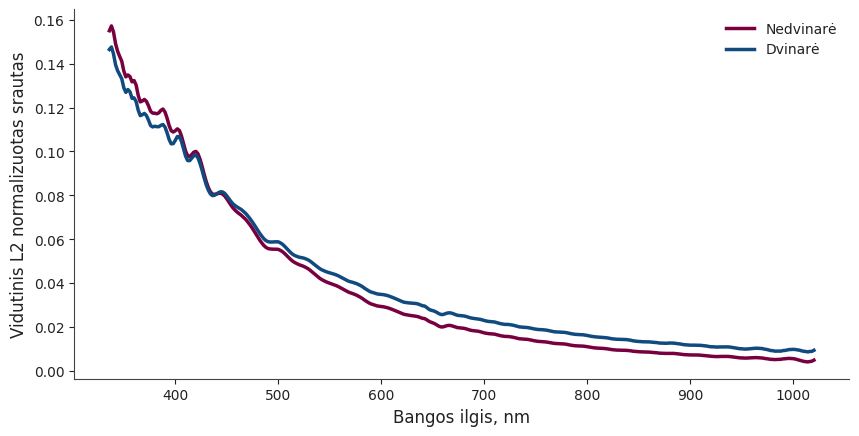

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_0, linewidth=2.5, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_1, linewidth=2.5, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 8. Plot: raw mean spectral difference

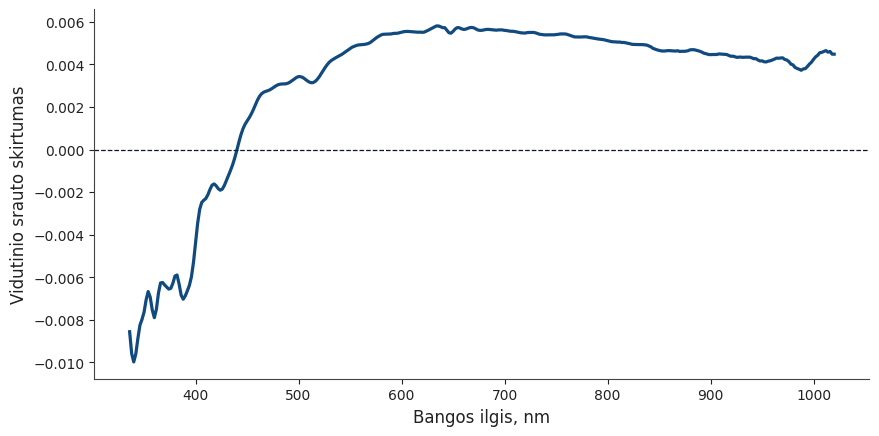

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, diff_10, linewidth=2.3, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinio srauto skirtumas")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 9. Plot: FPCA class separation

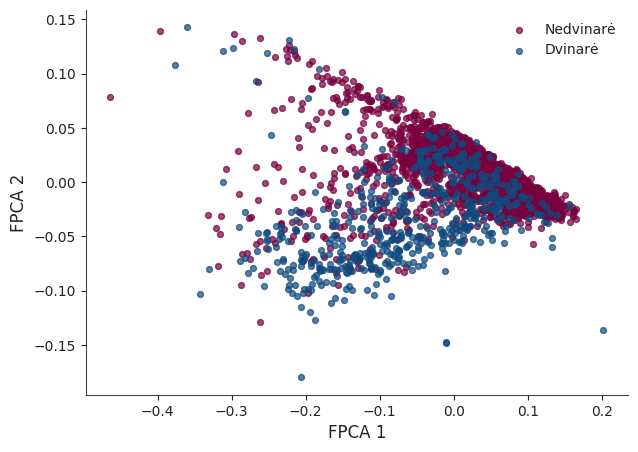

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    scores_fpca[y == 0, 0], scores_fpca[y == 0, 1],
    s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY
)
ax.scatter(
    scores_fpca[y == 1, 0], scores_fpca[y == 1, 1],
    s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY
)

ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 10. Plot: FPLS class separation

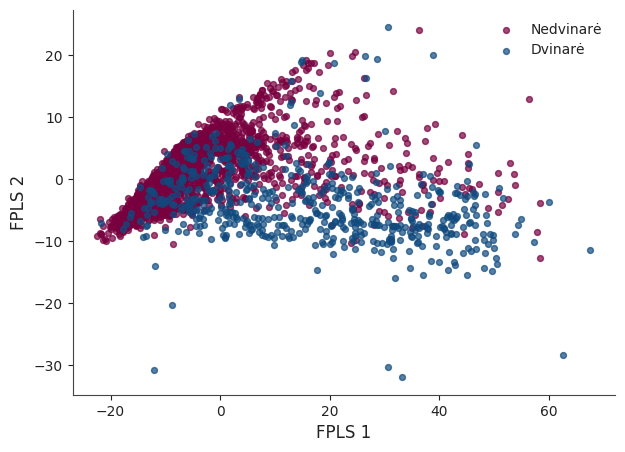

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    scores_fpls[y == 0, 0], scores_fpls[y == 0, 1],
    s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY
)
ax.scatter(
    scores_fpls[y == 1, 0], scores_fpls[y == 1, 1],
    s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY
)

ax.set_xlabel("FPLS 1")
ax.set_ylabel("FPLS 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 11. Plot: nearest-neighbour example

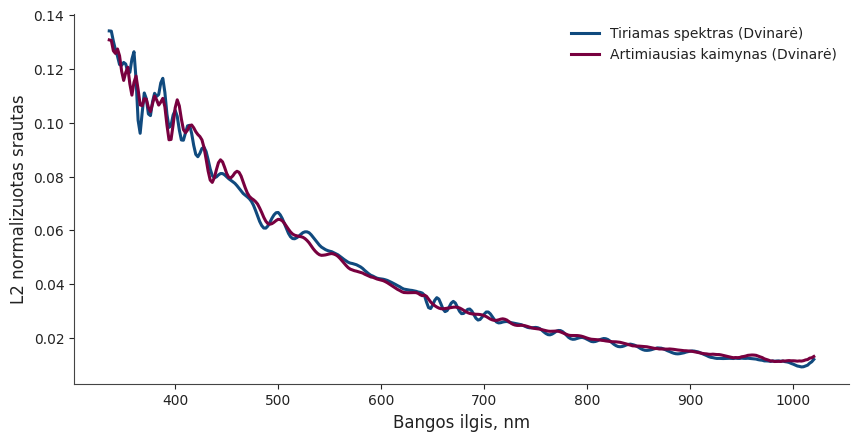

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, x_query, linewidth=2.2, color=COLOR_PRIMARY, label=f"Tiriamas spektras ({query_label_name})")
ax.plot(wavelengths, closest_curve, linewidth=2.2, color=COLOR_SECONDARY, label=f"Artimiausias kaimynas ({nn_label_name})")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 12. Plot: local distance contribution

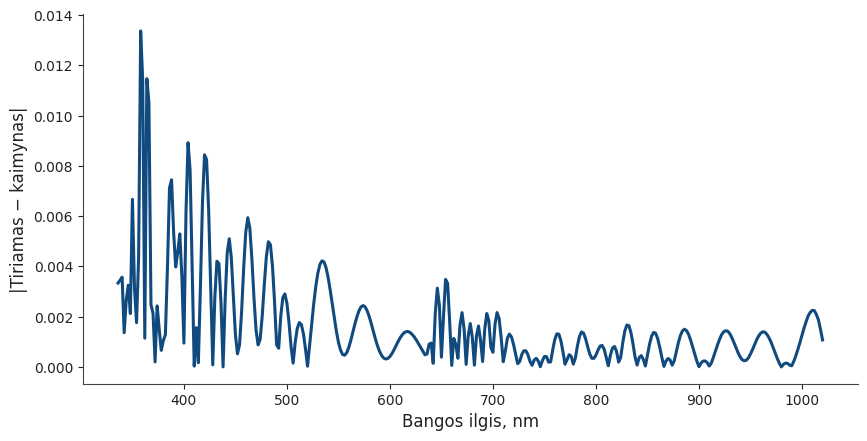

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, abs_diff, linewidth=2.2, color=COLOR_PRIMARY)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("|Tiriamas − kaimynas|")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 13. Plot: global distance contribution

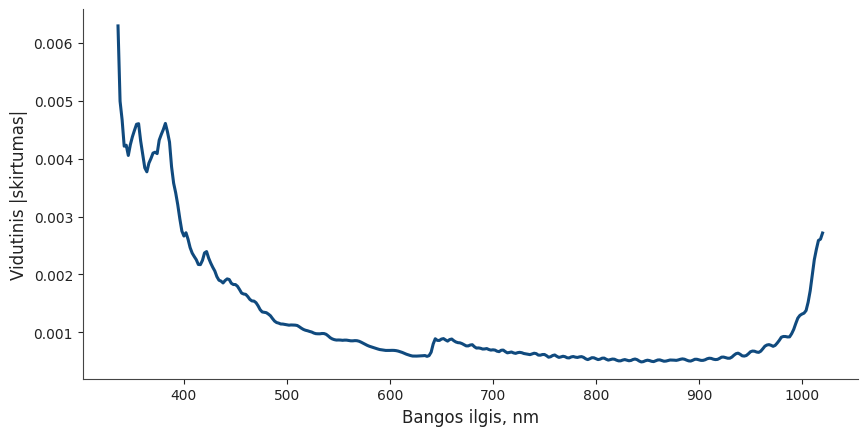

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_distance_contribution, linewidth=2.2, color=COLOR_PRIMARY)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis |skirtumas|")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 14. Plot: raw functional logistic regression weight function

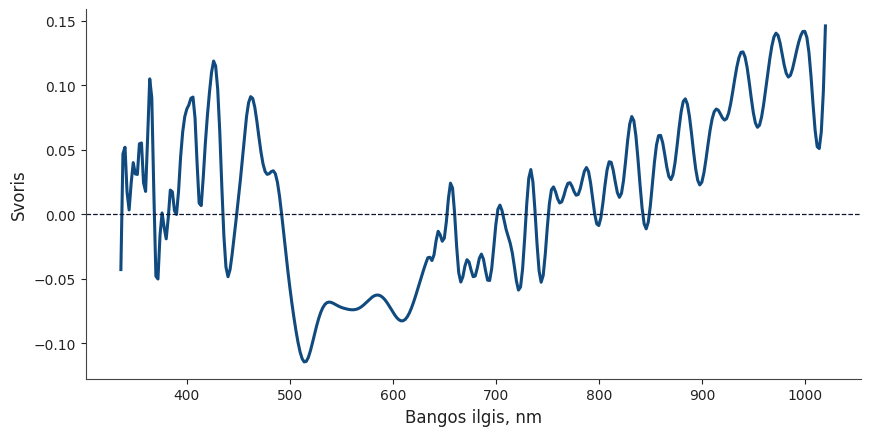

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_logreg, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 15. Plot: raw functional linear SVM weight function

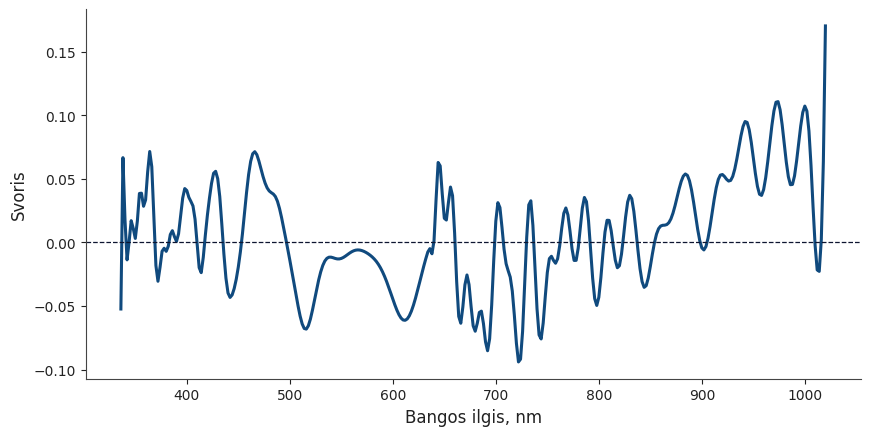

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_svm, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
plt.show()


## 16. Plot: comparison of raw linear-model weight curves

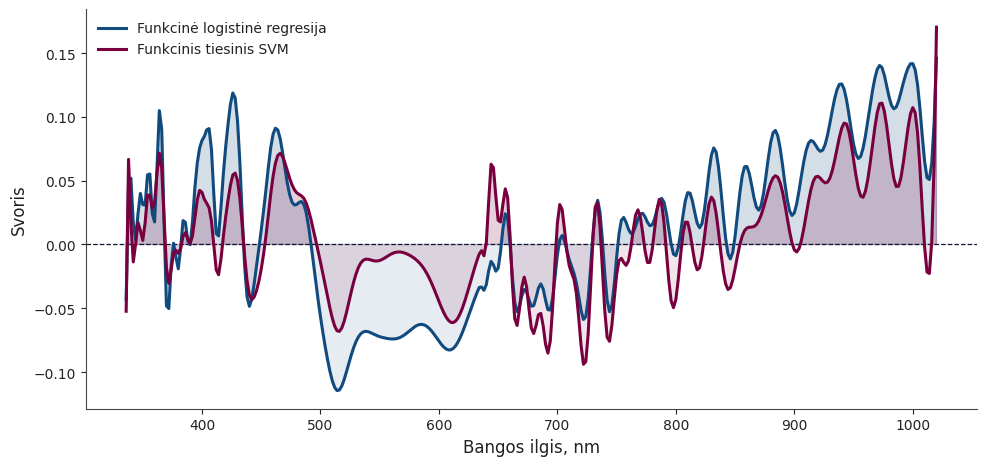

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))

# Linijos
ax.plot(
    wavelengths,
    beta_logreg,
    linewidth=2.2,
    color=COLOR_PRIMARY,
    label="Funkcinė logistinė regresija",
    zorder=3
)

ax.plot(
    wavelengths,
    beta_svm,
    linewidth=2.2,
    color=COLOR_SECONDARY,
    label="Funkcinis tiesinis SVM",
    zorder=3
)

# Fill LOGREG
ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg >= 0),
    color=COLOR_PRIMARY,
    alpha=0.18,
    interpolate=True,
    zorder=1
)

ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg < 0),
    color=COLOR_PRIMARY,
    alpha=0.10,
    interpolate=True,
    zorder=1
)

# Fill SVM
ax.fill_between(
    wavelengths,
    beta_svm,
    0,
    where=(beta_svm >= 0),
    color=COLOR_SECONDARY,
    alpha=0.18,
    interpolate=True,
    zorder=1
)

ax.fill_between(
    wavelengths,
    beta_svm,
    0,
    where=(beta_svm < 0),
    color=COLOR_SECONDARY,
    alpha=0.10,
    interpolate=True,
    zorder=1
)

# 0 linija
ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
    zorder=2
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")

ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)

plt.tight_layout()
plt.show()

## 20. Save main tables

In [18]:
coef_df_raw.to_csv(OUT_DIR / "coefficient_curves_raw.csv", index=False)
top_logreg.to_csv(OUT_DIR / "top_logreg_regions_raw.csv", index=False)
top_svm.to_csv(OUT_DIR / "top_svm_regions_raw.csv", index=False)

print("Saved main CSV outputs to:", OUT_DIR)


Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\06_interpretability


## 21. Save figures

In [19]:
# Raw class mean spectra
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_0, linewidth=2.5, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mean_1, linewidth=2.5, color=COLOR_PRIMARY, label="Dvinarė")
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_class_mean_spectra_raw.svg")

# Raw mean difference
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, diff_10, linewidth=2.3, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinio srauto skirtumas")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_mean_difference_raw.svg")

# FPCA scatter
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(scores_fpca[y == 0, 0], scores_fpca[y == 0, 1], s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY)
ax.scatter(scores_fpca[y == 1, 0], scores_fpca[y == 1, 1], s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY)
ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_fpca_scatter.svg")

# FPLS scatter
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(scores_fpls[y == 0, 0], scores_fpls[y == 0, 1], s=18, alpha=0.7, label="Nedvinarė", color=COLOR_SECONDARY)
ax.scatter(scores_fpls[y == 1, 0], scores_fpls[y == 1, 1], s=18, alpha=0.7, label="Dvinarė", color=COLOR_PRIMARY)
ax.set_xlabel("FPLS 1")
ax.set_ylabel("FPLS 2")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_fpls_scatter.svg")

# Nearest-neighbour example
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, x_query, linewidth=2.2, color=COLOR_PRIMARY, label=f"Tiriamas spektras ({query_label_name})")
ax.plot(wavelengths, closest_curve, linewidth=2.2, color=COLOR_SECONDARY, label=f"Artimiausias kaimynas ({nn_label_name})")
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_nearest_neighbour_example.svg")

# Local distance contribution
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, abs_diff, linewidth=2.2, color=COLOR_PRIMARY)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("|Tiriamas − kaimynas|")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_local_distance_contribution.svg")

# Global distance contribution
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, mean_distance_contribution, linewidth=2.2, color=COLOR_PRIMARY)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis |skirtumas|")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_global_distance_contribution.svg")

# Raw logistic regression weights
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_logreg, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_beta_logreg_raw.svg")

# Raw SVM weights
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(wavelengths, beta_svm, linewidth=2.2, color=COLOR_PRIMARY)
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=0.9)
ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_beta_svm_raw.svg")

# Raw weight comparison
fig, ax = plt.subplots(figsize=(10, 4.8))

# Linijos
ax.plot(
    wavelengths,
    beta_logreg,
    linewidth=2.2,
    color=COLOR_PRIMARY,
    label="Funkcinė logistinė regresija",
    zorder=3
)

ax.plot(
    wavelengths,
    beta_svm,
    linewidth=2.2,
    color=COLOR_SECONDARY,
    label="Funkcinis tiesinis SVM",
    zorder=3
)

# Fill LOGREG
ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg >= 0),
    color=COLOR_PRIMARY,
    alpha=0.18,
    interpolate=True,
    zorder=1
)

ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg < 0),
    color=COLOR_PRIMARY,
    alpha=0.10,
    interpolate=True,
    zorder=1
)

# Fill SVM
ax.fill_between(
    wavelengths,
    beta_svm,
    0,
    where=(beta_svm >= 0),
    color=COLOR_SECONDARY,
    alpha=0.18,
    interpolate=True,
    zorder=1
)

ax.fill_between(
    wavelengths,
    beta_svm,
    0,
    where=(beta_svm < 0),
    color=COLOR_SECONDARY,
    alpha=0.10,
    interpolate=True,
    zorder=1
)

# 0 linija
ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
    zorder=2
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")

ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)

plt.tight_layout()

save_fig(OUT_DIR / "fig_beta_compare_raw.svg")

